<a href="https://colab.research.google.com/github/Kathron/drb-eai-sum25/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Multimodal Fusion for Radiology Image-Caption Retrieval

## Objective

The goal of this assignment is to explore and compare two powerful techniques for multimodal machine learning: **cross-modal attention** and **contrastive learning**. You will implement both methods to tackle the task of **radiology image-caption retrieval**—learning to match medical images (e.g., X-rays, CTs, MRIs) with their corresponding descriptive captions from scientific literature. Finally, you will analyze the performance, scalability, and qualitative differences between the two approaches.

---

## Dataset: ROCO (Radiology Objects in Context)

You will use the **ROCO dataset** (specifically, the updated ROCOv2 is recommended). This dataset is publicly available and contains over 81,000 radiology images sourced from PubMed Central articles, each paired with its original text caption. It features a wide variety of modalities (X-ray, MRI, CT, Ultrasound, etc.), making it a rich and challenging benchmark.

**Dataset Links:**

* **GitHub (ROCOv2 - Primary Source):** [https://github.com/sctg-development/ROCOv2-radiology](https://github.com/sctg-development/ROCOv2-radiology)
    * This repository contains the most up-to-date information, data splits, and download instructions.
* **Hugging Face (ROCOv2 - Easy Access):** [https://huggingface.co/datasets/eltorio/ROCOv2-radiology](https://huggingface.co/datasets/eltorio/ROCOv2-radiology)
    * This is a very convenient way to access and use the dataset with modern libraries.


## Setup & Backbones

To focus on the fusion and learning mechanisms, you can use pre-trained encoders as feature extractors.

* **Image Encoder:** A pre-trained **ResNet-50** or a vision transformer (e.g., **ViT-B/32**). For better performance, you could explore a biomedically pre-trained vision model (like **BioMedCLIP**'s vision encoder).
* **Text Encoder:** A pre-trained **BERT** model. For better performance, a domain-specific model like **Bio-BERT** or **ClinicalBERT** is recommended.
* **Task:** The goal is **image-caption retrieval**.
    * **Image-to-Text Retrieval:** Given one radiology image, find its correct matching caption from a large pool of candidate captions.
    * **Text-to-Image Retrieval:** Given one text caption, find its correct matching image from a large pool of candidate images.
* **Evaluation:** You will use the **Recall@K (R@K)** metric for $K=1, 5, 10$. This measures the percentage of queries for which the correct item is found within the top $K$ retrieved results.

---

## Part 1: Cross-Modal Attention for Modality Fusion

In this section, you will build a model that *fuses* image and text information using an attention mechanism and then predicts a single *similarity score*.

### 1.1. Model Architecture (10 points)

1.  **Input:** Your model will take one image and one text caption as input.
2.  **Feature Extraction:** Pass the inputs through the backbone encoders to get image patch features $V \in \mathbb{R}^{k \times d_{img}}$ and text (word) features $T \in \mathbb{R}^{l \times d_{text}}$.
3.  **Cross-Attention Module:** Implement a **cross-modal attention** layer. A common approach is to use the text features as the **Query** (Q) and the image patch features as the **Key (K)** and **Value (V)**.
    * $Q = T \cdot W_Q$
    * $K = V \cdot W_K$
    * $V = V \cdot W_V$
    * $Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$
    * The output of this operation will be a "text-aware" representation of the image.
4.  **Pooling & Classification Head:**
    * Take the output of the attention mechanism (e.g., a learned `[CLS]` token embedding or an average-pooled vector) to get a single fused multimodal vector.
    * Pass this vector through a simple **MLP (classification head)** that outputs a single logit (a score between 0 and 1) representing the probability that the image and text are a match.

### 1.2. Training (15 points)

* **Loss Function:** Train your model as a **binary classifier**. Use the **Binary Cross-Entropy (BCE) Loss**.
* **Data Pairs:**
    * **Positive Pairs ($y=1$):** A (image, caption) pair that genuinely matches.
    * **Negative Pairs ($y=0$):** A (image, caption) pair from the dataset that does *not* match. You will need to create these by, for example, pairing an image with a random caption from another image (this is called "in-batch negative sampling" or "hard negative sampling").

### 1.3. Evaluation (Retrieval) (15 points)

To perform retrieval with this model, you must compare a query (e.g., 1 image) against *all* possible candidates in the test set (e.g., 5,000 captions).

* For a single image query $I$:
    * Run a forward pass of your model for $(I, T_1), (I, T_2), ..., (I, T_N)$ for all $N$ captions in the test set.
    * This will produce $N$ similarity scores.
    * Rank the captions $T_j$ based on these scores in descending order.
* Calculate the R@1, R@5, and R@10 metrics for both image-to-text and text-to-image retrieval.

---

## Part 2: Contrastive Learning for a Shared Embedding Space

In this section, you will build a *two-tower* model that learns to project images and text into a **shared latent space** using a contrastive loss. This is the core idea behind models like **CLIP** and **BioMedCLIP**.

### 2.1. Model Architecture (10 points)

1.  **Input:** Your model will take a *batch* of $(image, caption)$ pairs.
2.  **Encoders:**
    * **Image Encoder:** Pass the image through the CNN/ViT backbone, followed by a **pooling** layer and an **MLP projection head** to get a single image embedding $e_i \in \mathbb{R}^{d}$.
    * **Text Encoder:** Pass the caption through the BERT backbone, followed by a **pooling** layer (e.g., use the `[CLS]` token embedding) and an **MLP projection head** to get a single text embedding $e_t \in \mathbb{R}^{d}$.
    * **Crucial:** Both projection heads must output a vector of the *same dimension* $d$.
3.  **Normalization:** L2-normalize both $e_i$ and $e_t$ so that their dot product is equivalent to cosine similarity.

### 2.2. Training (15 points)

* **Loss Function:** Implement the **InfoNCE (Noise-Contrastive Estimation) Loss**.
* **Logic:** For a batch of $N$ $(image, caption)$ pairs:
    1.  Create the $N$ image embeddings $E_I$ and $N$ text embeddings $E_T$.
    2.  Calculate an $N \times N$ similarity matrix $S$, where $S_{ij} = e_{i_i} \cdot e_{t_j}$ (using cosine similarity).
    3.  The *diagonal* elements $S_{ii}$ represent the similarity between **positive pairs** (correctly matched).
    4.  The *off-diagonal* elements $S_{ij}$ ($i \neq j$) represent the similarity between **negative pairs** (mismatched).
    5.  The loss function's goal is to **maximize** the scores on the diagonal while **minimizing** the scores on the off-diagonal.
    6.  This is treated as an $N$-class classification problem (per row and per column). You will compute a cross-entropy loss over the rows (image-to-text) and a separate cross-entropy loss over the columns (text-to-image). The labels are simply `[0, 1, 2, ..., N-1]`.
    7.  Your final loss is the average of these two "symmetric" losses.

### 2.3. Evaluation (Retrieval) (15 points)

Retrieval with this model is much more efficient.

1.  **Offline Step:** Run *all* images and *all* captions in your test set through their respective encoders *once* to get two "galleries" of embeddings: $G_I$ (size $N \times d$) and $G_T$ (size $N \times d$).
2.  **Online Step:** To perform retrieval for a single image query $e_i$:
    * Calculate the cosine similarity (a single matrix-vector product) between $e_i$ and the *entire text gallery* $G_T$.
    * This gives you $N$ scores instantly. Rank the texts based on these scores.
3.  Calculate the R@1, R@5, and R@10 metrics.

---

## Part 3: Comparison and Analysis (20 points)

Write a report that addresses the following questions. This is the most important part of the assignment.

1.  **Performance Comparison:**
    * Create a table showing the R@1, R@5, and R@10 scores (for both image-to-text and text-to-image) for your Part 1 (Attention) and Part 2 (Contrastive) models.
    * Which model performed best on this task? Were you surprised by this?

2.  **Architectural & Scalability Analysis:**
    * Compare the *architectures*. What is the fundamental difference between a "fusion" model (Part 1) and a "two-tower" model (Part 2)?
    * Discuss the **scalability of retrieval**.
        * For Part 1, how many forward passes (computations) are required to retrieve the best caption for **1 image** from a gallery of 1 million captions?
        * For Part 2, how many computations are required for the same query (assuming the gallery is pre-computed)?
    * Based on this, which *architecture* (not your specific model, but the *approach*) is suitable for a web-scale search engine?

3.  **Representation Analysis:**
    * What does the *output* of each model represent? (Hint: one outputs a *similarity score*, the other outputs an *embedding*).
    * What are the pros and cons of learning a shared embedding space (Part 2) vs. learning a dedicated scoring function (Part 1)? Can the embeddings from Part 2 be used for any other tasks (e.g., zero-shot classification)?

4.  **Qualitative Analysis (Bonus Points):**
    * Pick one image from the test set (e.g., a chest X-ray). Show the top 3 retrieved text captions from both models.
    * Pick one text query from the test set (e.g., "Axial CT scan showing a lesion in the liver"). Show the top 3 retrieved images from both models.
    * Analyze the results. Do the models make different *kinds* of mistakes? Does one seem to capture fine-grained details (e.g., a specific "nodule" or "fracture") better, while the other captures more abstract concepts (e.g., "MRI of a brain")?

---

## Deliverables

1.  A link to a GitHub repository (or a `.zip` file) containing your code, organized into folders for Part 1 and Part 2.
2.  A PDF report (3-5 pages) containing:
    * Brief descriptions of your model implementations.
    * The comparison table (R@K scores).
    * Your written answers to all questions in Part 3.

    

## Download Dataset ##

In [ ]:
# Download ROCO dataset
!pip install -q datasets pillow

import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
import warnings
warnings.filterwarnings("ignore", message="The secret `HF_TOKEN`")

from datasets import load_dataset

roco = load_dataset("eltorio/ROCOv2-radiology")

print(roco)
print(roco["train"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

data/train-00000-of-00027.parquet:   0%|          | 0.00/497M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/59962 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/9904 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/9927 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/27 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'caption', 'cui'],
        num_rows: 59962
    })
    validation: Dataset({
        features: ['image', 'image_id', 'caption', 'cui'],
        num_rows: 9904
    })
    test: Dataset({
        features: ['image', 'image_id', 'caption', 'cui'],
        num_rows: 9927
    })
})
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=682x748 at 0x7B7E60985AF0>, 'image_id': 'ROCOv2_2023_train_000001', 'caption': 'Head CT demonstrating left parotiditis.', 'cui': ['C0040405']}


Head CT demonstrating left parotiditis.


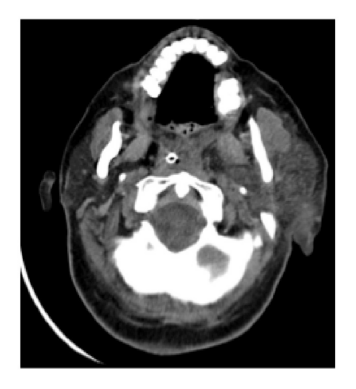

In [ ]:
# Display the image output from downloading dataset
from matplotlib import pyplot as plt

sample = roco["train"][0]

plt.imshow(sample["image"])
plt.axis("off")
print(sample["caption"])

## Setup ##

In [ ]:
# Load BioMedCLIP Vision Encoder and PubMedBERT Text Encoder
!pip install -q open_clip_torch

import torch
from open_clip import create_model_from_pretrained, get_tokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 1) BioMedCLIP model (ViT image encoder + PubMedBERT text encoder)
biomedclip_name = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"

biomedclip_model, biomedclip_preprocess = create_model_from_pretrained(biomedclip_name)
biomedclip_tokenizer = get_tokenizer(biomedclip_name)

biomedclip_model = biomedclip_model.to(device)
biomedclip_model.eval()

@torch.no_grad()
def encode_images(pil_images):
    """
    pil_images: list of PIL.Image objects
    returns: [N, D] L2-normalized BioMedCLIP image embeddings
    """
    imgs = torch.stack([biomedclip_preprocess(im) for im in pil_images]).to(device)
    emb = biomedclip_model.encode_image(imgs)               # [N, D]
    emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb

@torch.no_grad()
def encode_texts(captions):
    """
    captions: list of strings
    returns: [N, D] L2-normalized BioMedCLIP text embeddings (PubMedBERT)
    """
    tokens = biomedclip_tokenizer(captions)                 # [N, L] token ids
    tokens = tokens.to(device)
    emb = biomedclip_model.encode_text(tokens)              # [N, D]
    emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00
Using device: cuda


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
# Image-to-Text Retrieval
!pip install -q open_clip_torch==2.23.0

import torch
from open_clip import create_model_from_pretrained, get_tokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- Load BiomedCLIP (ViT image encoder + PubMedBERT text encoder) ----
model_name = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
vl_model, vl_preprocess = create_model_from_pretrained(model_name)
vl_tokenizer = get_tokenizer(model_name)

vl_model = vl_model.to(device)
vl_model.eval()

# ---- Build a small validation subset ----
num_items = 256   # can increase if memory allows
subset = [roco["validation"][i] for i in range(num_items)]
subset_images  = [ex["image"] for ex in subset]    # list of PIL images
subset_captions = [ex["caption"] for ex in subset] # list of strings

# ---- Encode images and captions with BiomedCLIP ----
with torch.no_grad():
    # Images -> embeddings
    image_tensors = torch.stack([vl_preprocess(img) for img in subset_images]).to(device)
    img_emb = vl_model.encode_image(image_tensors)
    img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)    # L2-normalize

    # Text -> embeddings (PubMedBERT inside BiomedCLIP)
    text_tokens = vl_tokenizer(subset_captions)               # token IDs
    text_tokens = text_tokens.to(device)
    txt_emb = vl_model.encode_text(text_tokens)
    txt_emb = txt_emb / txt_emb.norm(dim=-1, keepdim=True)    # L2-normalize

    # Cosine similarity matrix [N_images, N_texts]
    sim_matrix = img_emb @ txt_emb.T

N = sim_matrix.shape[0]
print(f"Computed embeddings and similarity matrix for N={N} image–caption pairs.")

# ---- Image → Text retrieval demo ----
k = 5           # top-k to print
num_queries_to_print = 3

for i in range(num_queries_to_print):
    scores, idxs = torch.topk(sim_matrix[i], k)
    print(f"\n=== Query IMAGE {i} (ground-truth caption) ===")
    print(subset_captions[i])

    print("\nTop-k retrieved captions:")
    for rank, (score, j) in enumerate(zip(scores.tolist(), idxs.tolist()), start=1):
        print(f"{rank}. score={score:.3f} | idx={j}")
        print("   ", subset_captions[j][:160], "...")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.4 MB/s eta 0:00:00
Using device: cuda
Computed embeddings and similarity matrix for N=256 image–caption pairs.

=== Query IMAGE 0 (ground-truth caption) ===
Chest X-ray showing enlarged cardiac silhouette with cardiothoracic ratio of 70%, and mild pulmonary congestion.

Top-k retrieved captions:
1. score=0.473 | idx=0
    Chest X-ray showing enlarged cardiac silhouette with cardiothoracic ratio of 70%, and mild pulmonary congestion. ...
2. score=0.393 | idx=75
    Initial chest x-ray on presentation to the emergency department ...
3. score=0.374 | idx=58
    Fifty-six-year-old man with atypical load-independent chest pain not extending further. Diffuse idiopathic skeletal hyperostosis (DISH), also referred to as For ...
4. score=0.366 | idx=201
    Chest x-ray showed no obvious patches or consolidations with normal costophrenic angles and cardiothoracic ratio. ...
5. score=0.361 | idx=108
    Erect chest X-ray showing normal ana


=== Query CAPTION 0 ===
Chest X-ray showing enlarged cardiac silhouette with cardiothoracic ratio of 70%, and mild pulmonary congestion.

Top-k retrieved images:
1. score=0.473 | image_idx=0


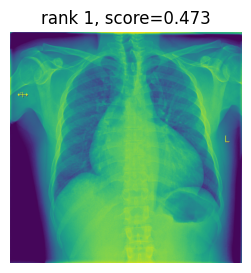

2. score=0.455 | image_idx=98


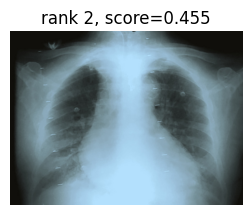

3. score=0.426 | image_idx=85


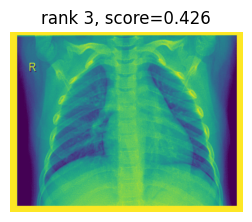

4. score=0.415 | image_idx=139


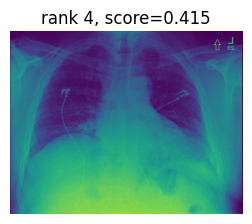

5. score=0.387 | image_idx=17


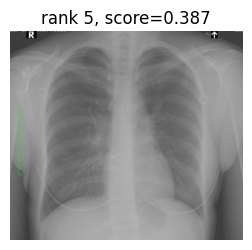


=== Query CAPTION 1 ===
Digital subtraction ureterogram with contrast injected as the sheath was retracted demonstrating a fistula between the distal ureter and an IMA branch (black arrow). Also seen, multiple filling defects within the left renal pelvis and left dilated proximal ureter, consistent with blood clots

Top-k retrieved images:
1. score=0.494 | image_idx=1


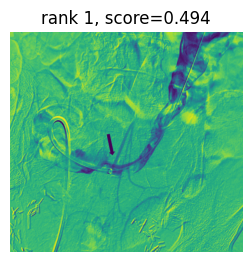

2. score=0.366 | image_idx=14


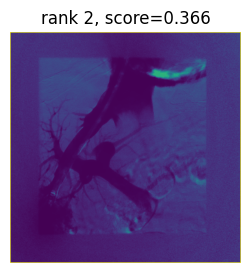

3. score=0.352 | image_idx=254


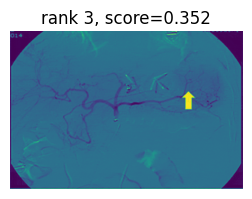

4. score=0.350 | image_idx=205


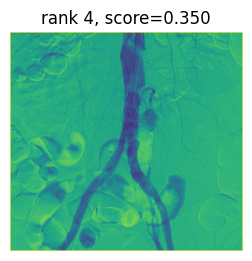

5. score=0.322 | image_idx=192


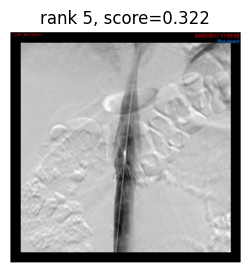


=== Query CAPTION 2 ===
Fifty-eight-year-old woman with 2 cancers: one seen on DBT but not visible with US, and one seen on US but not on DBT. She presented for screening with DBT. (A) Right 2D MLO view was negative, but asymmetry was seen (B) medially on the craniocaudal (CC) view. DBT (C) MLO and (D) CC views show architectural distortion (arrows) in the upper inner quadrant. US was negative in the upper inner quadrant (no image), but showed a suspicious mass in the 9 o’clock position (arrows in (E). (F) The upper inner quadrant mass was biopsied with DBT-guidance (scout view) and was an invasive lobular carcinoma. The 9 o’clock mass was biopsied with US-guidance and was an invasive ductal carcinoma.

Top-k retrieved images:
1. score=0.405 | image_idx=2


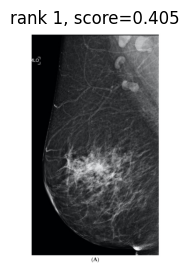

2. score=0.364 | image_idx=152


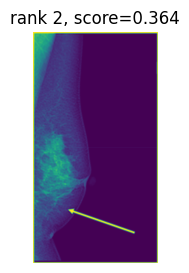

3. score=0.260 | image_idx=42


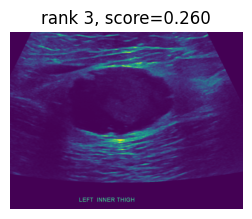

4. score=0.237 | image_idx=206


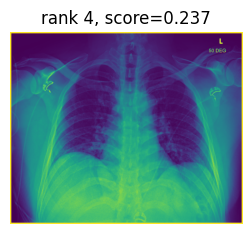

5. score=0.227 | image_idx=141


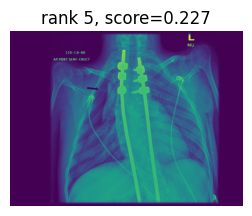

In [ ]:
# Text-to-Image Retrieval
import torch
from matplotlib import pyplot as plt

# Assumes sim_matrix, subset_images, subset_captions from previous cell
k = 5
num_queries_to_print = 3

for j in range(num_queries_to_print):
    # For text→image, treat caption j as query; rank all images
    # -> use column j of sim_matrix (or equivalently sim_matrix.T[j])
    scores, idxs = torch.topk(sim_matrix[:, j], k)

    print(f"\n=== Query CAPTION {j} ===")
    print(subset_captions[j])

    print("\nTop-k retrieved images:")
    for rank, (score, i) in enumerate(zip(scores.tolist(), idxs.tolist()), start=1):
        print(f"{rank}. score={score:.3f} | image_idx={i}")

        # show retrieved image
        plt.figure(figsize=(3, 3))
        plt.imshow(subset_images[i])
        plt.axis("off")
        plt.title(f"rank {rank}, score={score:.3f}")
        plt.show()

In [ ]:
# Evaluate Using the R@K Metric
import torch

def recall_at_k(sim, ks=(1, 5, 10)):
    """
    sim: [N, N] similarity matrix
         rows = queries, cols = candidates
    Assumes ground-truth match for query i is candidate i.
    """
    _, ranked_idxs = torch.sort(sim, dim=1, descending=True)  # [N, N]
    recalls = {}

    for K in ks:
        K_eff = min(K, sim.shape[1])
        correct = 0
        for i in range(sim.shape[0]):
            topk = ranked_idxs[i, :K_eff]
            if i in topk:
                correct += 1
        recalls[K] = correct / sim.shape[0]
    return recalls

N = sim_matrix.shape[0]
print(f"Evaluating R@K on N={N} pairs.")

# Image → Text: rows = images, cols = texts
i2t_recalls = recall_at_k(sim_matrix, ks=(1, 5, 10))
print("\nImage → Text Recall@K:")
for K, r in i2t_recalls.items():
    print(f"  R@{K}: {r*100:.2f}%")

# Text → Image: rows = texts, cols = images
t2i_recalls = recall_at_k(sim_matrix.T, ks=(1, 5, 10))
print("\nText → Image Recall@K:")
for K, r in t2i_recalls.items():
    print(f"  R@{K}: {r*100:.2f}%")

Evaluating R@K on N=256 pairs.

Image → Text Recall@K:
  R@1: 72.66%
  R@5: 95.70%
  R@10: 97.27%

Text → Image Recall@K:
  R@1: 75.39%
  R@5: 94.92%
  R@10: 97.66%


This means that:

**For Image-to-Text Retrieval:**
- R@1: 72.66% - For ~73% of image queries, BioMedCLIP retrieves the correct caption as the top most similar caption.
- R@5: 95.70% - For ~96% of image queries, the correct caption is somewhere in the top 5 retrieved captions.
- R@10: 97.27% - For ~97% of image queries, the correct caption is in the top 10 retrieved captions.

**For Text-to-Image Retrieval:**
- These results are slightly better, which is typical as captions contain more detailed semantics than images.

## Part 1: Cross-Modal Attention for Modality Fusion ##

**1.1. Model Architecture**

In [ ]:
# Input and Feature Selection
!pip install -q torch torchvision transformers

import torch
import torch.nn as nn
from torchvision import models, transforms
from transformers import AutoTokenizer, AutoModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- Image preprocessing for the CNN backbone ----
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet stats
        std=[0.229, 0.224, 0.225],
    ),
])

# ---- Text tokenizer for the text backbone ----
text_model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(text_model_name)


class ImageEncoder(nn.Module):
    """
    CNN backbone (ResNet-18) → patch features V ∈ R^{B×K×d_img}
    """
    def __init__(self, d_img=256):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # keep everything except the final pooling + fc
        self.cnn = nn.Sequential(*list(backbone.children())[:-2])  # [B, 512, H, W]
        self.proj = nn.Linear(512, d_img)

    def forward(self, images):
        """
        images: tensor [B, 3, 224, 224]
        returns: V [B, K, d_img], where K = H*W spatial patches
        """
        feats = self.cnn(images)          # [B, 512, H, W]
        B, C, H, W = feats.shape
        feats = feats.view(B, C, H * W)   # [B, 512, K]
        feats = feats.transpose(1, 2)     # [B, K, 512]
        V = self.proj(feats)              # [B, K, d_img]
        return V


class TextEncoder(nn.Module):
    """
    BERT backbone → token features T ∈ R^{B×L×d_text}
    """
    def __init__(self, model_name=text_model_name, d_text=256):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.proj = nn.Linear(self.bert.config.hidden_size, d_text)

    def forward(self, input_ids, attention_mask):
        """
        input_ids, attention_mask: [B, L]
        returns: T [B, L, d_text]
        """
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        token_feats = outputs.last_hidden_state      # [B, L, H]
        T = self.proj(token_feats)                   # [B, L, d_text]
        return T


class ImageTextFeatureExtractor(nn.Module):
    """
    Wraps both encoders and returns (V, T).
    """
    def __init__(self, d_model=256):
        super().__init__()
        self.img_encoder = ImageEncoder(d_img=d_model)
        self.txt_encoder = TextEncoder(d_text=d_model)

    def forward(self, images, input_ids, attention_mask):
        V = self.img_encoder(images)                          # [B, K, d_model]
        T = self.txt_encoder(input_ids, attention_mask)       # [B, L, d_model]
        return V, T


# instantiate feature extractor
feature_extractor = ImageTextFeatureExtractor(d_model=256).to(device)
feature_extractor.eval()

# Example of preparing a single batch (you'll use your ROCO DataLoader instead)
def prepare_batch(pil_images, captions, max_length=64):
    # images: list of PIL images
    # captions: list of strings
    img_tensors = torch.stack([image_transform(im) for im in pil_images])
    tokenized = tokenizer(
        captions,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    return (
        img_tensors.to(device),
        tokenized["input_ids"].to(device),
        tokenized["attention_mask"].to(device),
    )

Using device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
# Cross-Modal Attention Module
import math
import torch.nn.functional as F

class CrossModalAttention(nn.Module):
    """
    Single-head cross-attention:
      - Query Q from text features T
      - Key K and Value V from image patch features V_img
    """
    def __init__(self, d_model=256, d_k=None):
        super().__init__()
        if d_k is None:
            d_k = d_model

        self.W_Q = nn.Linear(d_model, d_k)
        self.W_K = nn.Linear(d_model, d_k)
        self.W_V = nn.Linear(d_model, d_model)
        self.scale = math.sqrt(d_k)

    def forward(self, T, V_img):
        """
        T: [B, L, d_model]  (text tokens)
        V_img: [B, K, d_model] (image patches)

        Returns:
            H: [B, L, d_model]  text-aware image representation
        """
        # 1. Linear projections
        Q = self.W_Q(T)          # [B, L, d_k]
        K = self.W_K(V_img)      # [B, K, d_k]
        V = self.W_V(V_img)      # [B, K, d_model]

        # 2. Scaled dot-product attention
        #    scores[b, i, j] = <Q_{b,i}, K_{b,j}> / sqrt(d_k)
        scores = torch.matmul(Q, K.transpose(1, 2)) / self.scale   # [B, L, K]
        attn_weights = F.softmax(scores, dim=-1)                   # over patches

        # 3. Weighted sum over image patches → text-aware image features
        H = torch.matmul(attn_weights, V)                          # [B, L, d_model]
        return H

# instantiate module
cross_attention = CrossModalAttention(d_model=256).to(device)
cross_attention.eval()

CrossModalAttention(
  (W_Q): Linear(in_features=256, out_features=256, bias=True)
  (W_K): Linear(in_features=256, out_features=256, bias=True)
  (W_V): Linear(in_features=256, out_features=256, bias=True)
)

In [ ]:
# Pooling and Classification Head
class CrossModalMatcher(nn.Module):
    """
    Full model:
      - feature_extractor: gives V (image patches) and T (text tokens)
      - cross_attention: produces text-aware image representation H
      - pooling + MLP: outputs a single match score in [0, 1] after sigmoid
    """
    def __init__(self, d_model=256):
        super().__init__()
        self.features = ImageTextFeatureExtractor(d_model=d_model)
        self.cross_attn = CrossModalAttention(d_model=d_model)

        # simple MLP classification head
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1)
        )

    def forward(self, images, input_ids, attention_mask):
        # 1) feature extraction
        V_img, T_txt = self.features(images, input_ids, attention_mask)  # [B,K,d], [B,L,d]

        # 2) cross-modal attention (text as Q, image patches as K,V)
        H = self.cross_attn(T_txt, V_img)   # [B, L, d]

        # 3) pooling: take CLS token (position 0) as fused representation
        fused = H[:, 0, :]                  # [B, d]  (uses BERT's [CLS] token)

        # 4) classification head → logit
        logit = self.classifier(fused).squeeze(-1)  # [B]
        return logit

    def predict_proba(self, images, input_ids, attention_mask):
        logit = self.forward(images, input_ids, attention_mask)
        return torch.sigmoid(logit)  # [B], probability of match

# instantiate the full model
cross_modal_model = CrossModalMatcher(d_model=256).to(device)
print("Number of trainable parameters:",
      sum(p.numel() for p in cross_modal_model.parameters() if p.requires_grad))

Number of trainable parameters: 121250369


In [ ]:
from torchvision import transforms as T

# Override/define image_transform so all images are 3-channel RGB
image_transform = T.Compose([
    T.Resize((224, 224)),
    # Ensure 3 channels even if the original image is grayscale
    T.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

**1.2. Training**

In [ ]:
# Loss Function
import torch
import torch.nn as nn

# We use BCEWithLogitsLoss because the model outputs raw logits
criterion = nn.BCEWithLogitsLoss()

def compute_bce_loss(model, images, input_ids, attention_mask, labels):
    """
    model: CrossModalMatcher
    images: [B, 3, 224, 224]
    input_ids, attention_mask: [B, L]
    labels: [B] with values 0 or 1

    Returns: scalar loss
    """
    # Forward pass: model returns logits (not probabilities)
    logits = model(images, input_ids, attention_mask)   # [B]

    # BCEWithLogitsLoss expects float labels
    loss = criterion(logits, labels.float())
    return loss

In [ ]:
# Data Pairs
import torch

def build_pos_neg_pairs(pil_images, captions, max_length=64):
    """
    pil_images: list of PIL images of length B
    captions:   list of strings of length B (matching captions)
    Returns:
        images_tensor:   [2B, 3, 224, 224]
        input_ids:       [2B, L]
        attention_mask:  [2B, L]
        labels:          [2B]  (first B = 1, next B = 0)
    """
    B = len(pil_images)
    assert B == len(captions)

    # --- 1. Convert images to tensors (shared for pos and neg) ---
    images_tensor = torch.stack([image_transform(im) for im in pil_images])  # [B,3,224,224]

    # --- 2. Positive captions (matching) ---
    pos_captions = captions

    # --- 3. Negative captions (mismatched) ---
    # Use a cyclic shift: caption_{i+1} pairs with image_i
    neg_indices = (torch.arange(B) + 1) % B
    neg_captions = [captions[int(j)] for j in neg_indices]

    # --- 4. Combine captions ---
    all_captions = pos_captions + neg_captions              # length 2B
    all_images   = torch.cat([images_tensor, images_tensor], dim=0)  # [2B,3,224,224]

    # --- 5. Tokenize captions ---
    tokenized = tokenizer(
        all_captions,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )

    input_ids      = tokenized["input_ids"]
    attention_mask = tokenized["attention_mask"]

    # --- 6. Labels: first B positives (1), next B negatives (0) ---
    labels = torch.cat([torch.ones(B), torch.zeros(B)], dim=0)

    # Move everything to the correct device
    all_images      = all_images.to(device)
    input_ids       = input_ids.to(device)
    attention_mask  = attention_mask.to(device)
    labels          = labels.to(device)

    return all_images, input_ids, attention_mask, labels

In [ ]:
# Training Loop for Cross-Modal Model
import torch, random, gc

# Use Adam optimizer
optimizer = torch.optim.Adam(
    cross_modal_model.parameters(),
    lr=1e-4
)

# Choose a subset of ROCO to train quickly
train_subset = roco["train"].select(range(3000))   # first 3,000 examples

num_epochs = 2
batch_size = 16
max_length = 64

cross_modal_model.train()

for epoch in range(num_epochs):
    losses = []
    idxs = list(range(len(train_subset)))
    random.shuffle(idxs)

    for start in range(0, len(idxs), batch_size):
        batch_idx = idxs[start:start + batch_size]
        if len(batch_idx) < 2:
            continue

        # Load PIL images + captions
        pil_images = [train_subset[i]["image"] for i in batch_idx]
        captions   = [train_subset[i]["caption"] for i in batch_idx]

        # Build positives + negatives
        images_tensor, input_ids, attn_mask, labels = build_pos_neg_pairs(
            pil_images, captions, max_length=max_length
        )

        # Compute loss
        optimizer.zero_grad()
        loss = compute_bce_loss(
            cross_modal_model,
            images_tensor,
            input_ids,
            attn_mask,
            labels
        )

        # Update model
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        # free memory
        del images_tensor, input_ids, attn_mask, labels
        gc.collect()
        torch.cuda.empty_cache()

    print(f"Epoch {epoch+1}/{num_epochs}, mean loss = {sum(losses)/len(losses):.4f}")

print("Training complete.")

Epoch 1/2, mean loss = 0.6933
Epoch 2/2, mean loss = 0.6932
Training complete.


**1.3. Evaluation**

In [ ]:
# Compare a Single Query
import torch

cross_modal_model.eval()  # evaluation mode

@torch.no_grad()
def score_image_against_captions(model, query_image, candidate_captions,
                                 batch_size=64, max_length=64):
    """
    query_image: single PIL image
    candidate_captions: list of N strings
    Returns:
        scores: tensor [N] of similarity logits (higher = more similar)
    """
    model = model.to(device)
    # Preprocess the query image once
    img_tensor = image_transform(query_image).unsqueeze(0).to(device)  # [1,3,224,224]

    all_scores = []

    N = len(candidate_captions)
    for start in range(0, N, batch_size):
        caps_batch = candidate_captions[start:start + batch_size]
        b = len(caps_batch)

        # Repeat the single image b times to pair with each caption
        images_batch = img_tensor.repeat(b, 1, 1, 1)  # [b,3,224,224]

        tokens = tokenizer(
            caps_batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        input_ids = tokens["input_ids"].to(device)
        attention_mask = tokens["attention_mask"].to(device)

        logits = model(images_batch, input_ids, attention_mask)  # [b]
        all_scores.append(logits.cpu())

    scores = torch.cat(all_scores, dim=0)  # [N]
    return scores


@torch.no_grad()
def rank_captions_for_image(model, query_image, candidate_captions, top_k=10):
    """
    Returns:
        sorted_indices: tensor [N] of caption indices sorted by similarity (desc)
        top_caps: list of the top_k captions
        top_scores: tensor [top_k] of scores
    """
    scores = score_image_against_captions(model, query_image, candidate_captions)
    sorted_indices = torch.argsort(scores, descending=True)  # [N]

    k = min(top_k, len(candidate_captions))
    top_indices = sorted_indices[:k]
    top_caps = [candidate_captions[i] for i in top_indices]
    top_scores = scores[top_indices]

    return sorted_indices, top_caps, top_scores

In [ ]:
# Evaluate Using the R@K Metric
import torch
import math

@torch.no_grad()
def evaluate_recall_at_k_crossmodal(model, dataset, N_eval=256, Ks=(1, 5, 10),
                                    batch_size=64, max_length=64):
    """
    dataset: a HuggingFace Dataset with fields "image" and "caption" (e.g., roco["test"])
    N_eval: number of (image, caption) pairs from the start of the dataset to evaluate
    """
    model.eval()
    model = model.to(device)

    N = min(N_eval, len(dataset))
    print(f"Evaluating R@K on N={N} pairs.")

    # Collect the first N images & captions
    images = [dataset[i]["image"] for i in range(N)]
    captions = [dataset[i]["caption"] for i in range(N)]

    # Precompute all image tensors once (for text→image)
    img_tensors = torch.stack([image_transform(im) for im in images])  # [N,3,224,224]
    img_tensors = img_tensors.to(device)

    # ---------- Image → Text ----------
    ranks_i2t = []

    for i in range(N):
        query_img = images[i]

        # Score this image against all captions
        scores = score_image_against_captions(
            model, query_img, captions,
            batch_size=batch_size, max_length=max_length
        )  # [N]

        sorted_indices = torch.argsort(scores, descending=True)
        # Rank of the correct caption (index i) in this sorted list
        rank = (sorted_indices == i).nonzero(as_tuple=True)[0].item() + 1  # 1-based
        ranks_i2t.append(rank)

    # ---------- Text → Image ----------
    ranks_t2i = []

    for j in range(N):
        query_cap = captions[j]

        # Tokenize the single query caption once
        tokens = tokenizer(
            [query_cap],
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        q_input_ids = tokens["input_ids"].to(device)
        q_attn_mask = tokens["attention_mask"].to(device)

        all_scores = []
        # We will pair this one caption with all images in batches
        for start in range(0, N, batch_size):
            end = min(start + batch_size, N)
            imgs_batch = img_tensors[start:end]                  # [b,3,224,224]
            b = imgs_batch.size(0)

            # Repeat caption b times to match images
            input_ids = q_input_ids.repeat(b, 1)                 # [b,L]
            attn_mask = q_attn_mask.repeat(b, 1)                 # [b,L]

            logits = model(imgs_batch, input_ids, attn_mask)     # [b]
            all_scores.append(logits.cpu())

        scores = torch.cat(all_scores, dim=0)                    # [N]
        sorted_indices = torch.argsort(scores, descending=True)
        rank = (sorted_indices == j).nonzero(as_tuple=True)[0].item() + 1
        ranks_t2i.append(rank)

    # ---------- Compute Recall@K ----------
    def recall_at_k(ranks, K):
        ranks = torch.tensor(ranks)
        return (ranks <= K).float().mean().item()

    print("\nImage → Text Recall@K:")
    for K in Ks:
        r = recall_at_k(ranks_i2t, K) * 100.0
        print(f"  R@{K}: {r:.2f}%")

    print("\nText → Image Recall@K:")
    for K in Ks:
        r = recall_at_k(ranks_t2i, K) * 100.0
        print(f"  R@{K}: {r:.2f}%")

In [ ]:
# Run the R@K Evaluation for Cross-Modal Attention Model
evaluate_recall_at_k_crossmodal(
    cross_modal_model,
    roco["test"],
    N_eval=256,     # this can be 256, 128 or 64 if CPU is slow
    Ks=(1, 5, 10),
    batch_size=32
)

Evaluating R@K on N=256 pairs.

Image → Text Recall@K:
  R@1: 0.39%
  R@5: 3.52%
  R@10: 7.42%

Text → Image Recall@K:
  R@1: 0.39%
  R@5: 1.95%
  R@10: 3.91%


This means that:

These results are far *worse* than the setup R@K results (from BioMedCLIP), which is expected. However, these results are still better than random.

The fact that this was only slightly better than random highlights that training such a large fusion model from scratch requires more data and computation power. In contrast, the setup R@K results demonstrate the power of a large-scale pre-trained contrastive model (BioMedCLIP).

## Part 2: Contrastive Learning for a Shared Embedding Space ##

**2.1. Model Architecture**


In [ ]:
# Input and Feature Selection for Contrastive Image–Text Model
import torch
import torch.nn as nn
from torchvision import models
from transformers import AutoModel

print("Using device:", device)

# Image Encoder + Projection Head
class ContrastiveImageEncoder(nn.Module):
    """
    Image encoder:
      CNN backbone → global pooling → MLP projection head → e_i ∈ R^d
    """
    def __init__(self, d_out=256):
        super().__init__()

        # Reuse a ResNet backbone (similar to Part 1, but pooled to a single vector)
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # Keep everything up to the final avgpool (drop the last FC layer)
        self.cnn = nn.Sequential(*list(backbone.children())[:-1])  # [B, 512, 1, 1]

        # Simple MLP projection head mapping 512 → d_out
        self.proj = nn.Sequential(
            nn.Linear(512, d_out),
            nn.ReLU(),
            nn.Linear(d_out, d_out),
        )

    def forward(self, images):
        """
        images: [B, 3, 224, 224]
        returns: L2-normalized image embeddings e_i ∈ R^{B×d_out}
        """
        x = self.cnn(images)          # [B, 512, 1, 1]
        x = x.flatten(1)              # [B, 512]
        x = self.proj(x)              # [B, d_out]
        # L2-normalize so dot product ≈ cosine similarity
        x = x / x.norm(dim=-1, keepdim=True)
        return x

# Text Encoder + Projection Head
class ContrastiveTextEncoder(nn.Module):
    """
    Text encoder:
      BERT backbone → [CLS] pooling → MLP projection head → e_t ∈ R^d
    """
    def __init__(self, model_name=text_model_name, d_out=256):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)

        self.proj = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size, d_out),
            nn.ReLU(),
            nn.Linear(d_out, d_out),
        )

    def forward(self, input_ids, attention_mask):
        """
        input_ids, attention_mask: [B, L]
        returns: L2-normalized text embeddings e_t ∈ R^{B×d_out}
        """
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]   # [CLS] token embedding [B, H]
        x = self.proj(cls)                         # [B, d_out]
        # L2-normalize so dot product ≈ cosine similarity
        x = x / x.norm(dim=-1, keepdim=True)
        return x

# Wrapper: two-tower image–text model
class ImageTextContrastiveModel(nn.Module):
    """
    Two-tower contrastive model:
      - img_encoder: images → e_i
      - txt_encoder: captions → e_t
    Both embeddings live in the same d-dimensional space and are L2-normalized.
    """
    def __init__(self, d_out=256):
        super().__init__()
        self.img_encoder = ContrastiveImageEncoder(d_out=d_out)
        self.txt_encoder = ContrastiveTextEncoder(d_out=d_out)

    def forward(self, images, input_ids, attention_mask):
        """
        Returns:
            e_i: [B, d_out] image embeddings
            e_t: [B, d_out] text embeddings
        """
        e_i = self.img_encoder(images)
        e_t = self.txt_encoder(input_ids, attention_mask)
        return e_i, e_t

# Instantiate the contrastive model
contrastive_model = ImageTextContrastiveModel(d_out=256).to(device)

print(
    "Contrastive model parameters:",
    sum(p.numel() for p in contrastive_model.parameters() if p.requires_grad),
)

# Helper: prepare a batch of (image, caption)
def prepare_contrastive_batch(pil_images, captions, max_length=64):
    """
    pil_images: list of PIL images
    captions:   list of strings

    Returns:
        images_tensor: [B, 3, 224, 224]
        input_ids:     [B, L]
        attention_mask:[B, L]
    """
    # Reuse the same preprocessing & tokenizer as in Part 1
    img_tensors = torch.stack([image_transform(im) for im in pil_images])

    tokenized = tokenizer(
        captions,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )

    return (
        img_tensors.to(device),
        tokenized["input_ids"].to(device),
        tokenized["attention_mask"].to(device),
    )

Using device: cuda
Contrastive model parameters: 121118528


In [ ]:
# Similarity Head
import torch.nn as nn

class ContrastiveSimilarityHead(nn.Module):
    """
    Given L2-normalized image and text embeddings:
      e_i ∈ R^{B×d}, e_t ∈ R^{B×d}
    compute a similarity matrix S ∈ R^{B×B}, where:
      S[b_i, b_t] = cosine similarity between image b_i and text b_t.

    We also include a temperature hyperparameter (τ) to scale the logits
    for the InfoNCE loss (used in Section 2.2).
    """
    def __init__(self, temperature: float = 0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, e_i, e_t):
        """
        e_i: [B, d]  (normalized image embeddings)
        e_t: [B, d]  (normalized text embeddings)

        Returns:
            logits_i2t: [B, B] image-to-text similarity scores
            logits_t2i: [B, B] text-to-image similarity scores (transpose)
        """
        # Because e_i and e_t are L2-normalized, dot product == cosine similarity
        sim_matrix = e_i @ e_t.T          # [B, B]

        # Scale by temperature for use with cross-entropy in InfoNCE
        logits_i2t = sim_matrix / self.temperature   # image → text
        logits_t2i = logits_i2t.T                    # text → image

        return logits_i2t, logits_t2i


# Instantiate the similarity head
similarity_head = ContrastiveSimilarityHead(temperature=0.07).to(device)
print("Similarity head created with temperature =", similarity_head.temperature)

Similarity head created with temperature = 0.07


In [ ]:
# End-to-End Forward Pass
import torch

def forward_contrastive_batch(pil_images, captions,
                              backbone_model=None,
                              sim_head=None,
                              max_length: int = 64):

    assert backbone_model is not None, "Pass in your ImageTextContrastiveModel."
    assert sim_head is not None, "Pass in your ContrastiveSimilarityHead."

    # 1) Preprocess inputs
    images_tensor, input_ids, attention_mask = prepare_contrastive_batch(
        pil_images, captions, max_length=max_length
    )

    # 2) Encode to get normalized embeddings
    backbone_model.eval()
    sim_head.eval()
    with torch.no_grad():
        e_i, e_t = backbone_model(images_tensor, input_ids, attention_mask)

        # 3) Similarity logits (used later for InfoNCE)
        logits_i2t, logits_t2i = sim_head(e_i, e_t)

    return e_i, e_t, logits_i2t, logits_t2i

**2.2. Training**


In [ ]:
# Loss Function
import torch
import torch.nn as nn

# Cross-entropy for InfoNCE: N-way classification
infonce_criterion = nn.CrossEntropyLoss()

def compute_infonce_loss(model,
                         sim_head,
                         images,
                         input_ids,
                         attention_mask):

    # 1) Encode to get L2-normalized embeddings
    e_i, e_t = model(images, input_ids, attention_mask)  # e_i, e_t ∈ R^{N×d}

    # 2) Similarity matrix S = e_i · e_t^T / τ  (already scaled by temperature)
    logits_i2t, logits_t2i = sim_head(e_i, e_t)          # both ∈ R^{N×N}

    # 3) Labels are just [0, 1, ..., N-1]
    batch_size = logits_i2t.size(0)
    labels = torch.arange(batch_size, device=images.device)

    # 4) Image-to-text and text-to-image cross-entropy losses
    loss_i2t = infonce_criterion(logits_i2t, labels)   # rows: each image chooses its caption
    loss_t2i = infonce_criterion(logits_t2i, labels)   # columns: each caption chooses its image

    # 5) Final symmetric loss = average
    loss = 0.5 * (loss_i2t + loss_t2i)
    return loss

In [ ]:
# Data Pairs
import torch

def build_contrastive_pairs(pil_images, captions, max_length=64):
    images_tensor, input_ids, attention_mask = prepare_contrastive_batch(
        pil_images,
        captions,
        max_length=max_length,
    )
    return images_tensor, input_ids, attention_mask

In [ ]:
# Contrastive Training Loop
import random

# Optimize BOTH towers + similarity head
contrastive_optimizer = torch.optim.Adam(
    list(contrastive_model.parameters()) +
    list(similarity_head.parameters()),
    lr=1e-4,
)

# Choose a subset of ROCO to train quickly (can adjust size)
contrastive_train_subset = roco["train"].select(range(3000))  # first 3,000 examples

num_epochs = 2
batch_size = 16
max_length = 64

contrastive_model.train()
similarity_head.train()

for epoch in range(num_epochs):
    losses = []
    idxs = list(range(len(contrastive_train_subset)))
    random.shuffle(idxs)

    for start in range(0, len(idxs), batch_size):
        batch_idx = idxs[start:start + batch_size]

        # Need at least 2 examples for a meaningful N×N similarity matrix
        if len(batch_idx) < 2:
            continue

        # 1) Load PIL images + captions for this mini-batch
        pil_images = [contrastive_train_subset[i]["image"]   for i in batch_idx]
        captions   = [contrastive_train_subset[i]["caption"] for i in batch_idx]

        # 2) Build positive pairs (other examples in the batch provide negatives)
        images_tensor, input_ids, attn_mask = build_contrastive_pairs(
            pil_images,
            captions,
            max_length=max_length,
        )

        # 3) Compute symmetric InfoNCE loss
        contrastive_optimizer.zero_grad()
        loss = compute_infonce_loss(
            contrastive_model,
            similarity_head,
            images_tensor,
            input_ids,
            attn_mask,
        )

        # 4) Backprop + update
        loss.backward()
        contrastive_optimizer.step()

        losses.append(loss.item())

    mean_loss = sum(losses) / len(losses)
    print(f"Epoch {epoch+1}/{num_epochs}, mean InfoNCE loss = {mean_loss:.4f}")

print("Contrastive training complete.")

Epoch 1/2, mean InfoNCE loss = 2.2607
Epoch 2/2, mean InfoNCE loss = 1.6407
Contrastive training complete.


In [ ]:
# Freeze CNN and BERT Backbone Weights
# Train Only Projection Heads
for p in contrastive_model.img_encoder.cnn.parameters():
    p.requires_grad = False

for p in contrastive_model.txt_encoder.bert.parameters():
    p.requires_grad = False

# Re-create optimizer so it only sees trainable parameters
contrastive_optimizer = torch.optim.Adam(
    list(filter(lambda p: p.requires_grad, contrastive_model.parameters())) +
    list(similarity_head.parameters()),
    lr=1e-3,   # can be a bit higher since we train only small heads
)

print("Trainable parameters after freezing:",
      sum(p.numel() for p in contrastive_model.parameters() if p.requires_grad) +
      sum(p.numel() for p in similarity_head.parameters() if p.requires_grad))

Trainable parameters after freezing: 459776


In [ ]:
# Use a Larger Subset of ROCO Dataset
max_train_examples = 10000
contrastive_train_subset = roco["train"].select(range(max_train_examples))

len(contrastive_train_subset)

10000

In [ ]:
# Extra Contrastive Training Epochs
import random
import torch

extra_epochs = 5          # number of additional epochs
batch_size = 32           # slightly larger batch is fine if GPU memory allows
max_length = 64

contrastive_model.train()
similarity_head.train()

for epoch in range(extra_epochs):
    losses = []
    idxs = list(range(len(contrastive_train_subset)))
    random.shuffle(idxs)

    for start in range(0, len(idxs), batch_size):
        batch_idx = idxs[start:start + batch_size]
        if len(batch_idx) < 2:
            continue

        pil_images = [contrastive_train_subset[i]["image"]   for i in batch_idx]
        captions   = [contrastive_train_subset[i]["caption"] for i in batch_idx]

        images_tensor, input_ids, attn_mask = build_contrastive_pairs(
            pil_images,
            captions,
            max_length=max_length,
        )

        contrastive_optimizer.zero_grad()
        loss = compute_infonce_loss(
            contrastive_model,
            similarity_head,
            images_tensor,
            input_ids,
            attn_mask,
        )
        loss.backward()
        contrastive_optimizer.step()

        losses.append(loss.item())

    mean_loss = sum(losses) / len(losses)
    print(f"[Extra Epoch {epoch+1}/{extra_epochs}] mean InfoNCE loss = {mean_loss:.4f}")

print("Extra contrastive training complete.")

[Extra Epoch 1/5] mean InfoNCE loss = 2.1688
[Extra Epoch 2/5] mean InfoNCE loss = 2.0423
[Extra Epoch 3/5] mean InfoNCE loss = 1.9846
[Extra Epoch 4/5] mean InfoNCE loss = 1.9473
[Extra Epoch 5/5] mean InfoNCE loss = 1.9111
Extra contrastive training complete.


**2.3. Evaluation**


In [ ]:
# Offline Step
import torch

# Use ALL examples from the ROCO test split
contrastive_test_subset = roco["test"]      # HF Dataset

contrastive_model.eval()

image_gallery = []
text_gallery = []
test_captions = []

with torch.no_grad():
    batch_size = 32   # adjust if you hit OOM
    N = len(contrastive_test_subset)
    for start in range(0, N, batch_size):
        end = min(N, start + batch_size)

        # HuggingFace Dataset slicing → dict of lists
        batch = contrastive_test_subset[start:end]

        # Now grab the columns directly
        pil_images = batch["image"]      # list of PIL images
        captions   = batch["caption"]    # list of strings

        # Save captions for later inspection / metrics
        test_captions.extend(captions)

        # Preprocess and encode
        images_tensor, input_ids, attn_mask = prepare_contrastive_batch(
            pil_images,
            captions,
            max_length=64,
        )

        e_i, e_t = contrastive_model(images_tensor, input_ids, attn_mask)
        # e_i, e_t are already L2-normalized

        image_gallery.append(e_i.cpu())
        text_gallery.append(e_t.cpu())

# Final galleries: G_I and G_T, each of shape [N, d]
G_I = torch.cat(image_gallery, dim=0)   # image embeddings
G_T = torch.cat(text_gallery, dim=0)    # text embeddings

print("G_I shape:", G_I.shape)
print("G_T shape:", G_T.shape)
print("Number of test examples (N):", len(contrastive_test_subset))

G_I shape: torch.Size([9927, 256])
G_T shape: torch.Size([9927, 256])
Number of test examples (N): 9927


In [ ]:
# Online Step
import torch

def retrieve_text_for_image(query_index, G_I, G_T, captions, top_k=5):
    # 1 × d query embedding
    e_q = G_I[query_index:query_index + 1]          # [1, d]

    # Cosine similarity = dot product because embeddings are L2-normalized
    scores = (e_q @ G_T.T).squeeze(0)              # [N]

    topk_scores, topk_indices = scores.topk(top_k)

    print(f"Query index: {query_index}")
    print("Ground-truth caption:")
    print("  ", captions[query_index])
    print("\nTop retrieved captions:")
    for rank, (idx, sc) in enumerate(zip(topk_indices.tolist(), topk_scores.tolist()), start=1):
        marker = " (GT)" if idx == query_index else ""
        print(f"  {rank}. [idx={idx}] score={sc:.4f}{marker}")
        print("     ", captions[idx])

    return topk_indices, topk_scores


# Example usage (you can change query_index):
_ = retrieve_text_for_image(
    query_index=0,
    G_I=G_I,
    G_T=G_T,
    captions=test_captions,
    top_k=5,
)

Query index: 0
Ground-truth caption:
   CT chest axial view showing a huge ascending aortic aneurysm (*).

Top retrieved captions:
  1. [idx=1559] score=0.7682
      Small right pneumothorax with numerous thin-walled cystic lesions in both lungs, the largest measuring approximately 1.3x1.6 cm.
  2. [idx=3783] score=0.7661
      Thoracic duct lymphography in a Fontan patient with plastic bronchitis: note the dilated thoracic duct with multiple and bilateral leaks toward the lungs (white arrow).
  3. [idx=1252] score=0.7649
      Middle lobe pulmonary changes in the single patient regarded as indeterminate for COVID-19 infection.
  4. [idx=9839] score=0.7639
       Left hydropneumothorax as observed by chest computed tomography scan.
  5. [idx=5535] score=0.7625
      Small pulmonary embolism in the right lower lobe.


In [ ]:
# Evaluate Contrastive Model on the First 256 Test Examples
# Same Samples Part 1 is Evaluated On
N_eval = 256
subset_GI = G_I[:N_eval]   # [N_eval, d] image embeddings
subset_GT = G_T[:N_eval]   # [N_eval, d] text embeddings

# Compute similarity matrix for these subsets
sim_small = subset_GI @ subset_GT.T   # cosine sim if embeddings are L2-normalised

# Use the recall_at_k() function defined earlier
recalls_small = recall_at_k(sim_small, ks=(1, 5, 10))

print(f"R@1  (N={N_eval}) = {recalls_small[1]:.4f}")
print(f"R@5  (N={N_eval}) = {recalls_small[5]:.4f}")
print(f"R@10 (N={N_eval}) = {recalls_small[10]:.4f}")

R@1  (N=256) = 0.0664
R@5  (N=256) = 0.2305
R@10 (N=256) = 0.3828


This means that:

**How Good Is This:**

For N=256 samples, a *random* model would result in:
- R@1 = 1/256 = 0.004 (approximately)
- R@5 = 5/256 = 0.020 (approximately)
- R@10 = 10/256 = 0.039 (approximately)

**Contrastive Model:**
- R@1 = 0.0664/0.004 = 16.6
  - The contrastive model functions 16.6 times better than random.

- R@5 = 0.2305/0.020 = 11.525
  - The contrastive model runs ~11.5 times better than random.

- R@10 = 0.3828/0.039 = 9.815 (approximately)
  - The contrastive model runs ~9.8 times better than random.

**Overall:**

This is a substantial improvement from the setup R@K, which was essentially random. But is still worse than the BioMedCLIP Baseline from Part 1, which is to be expected as that has been pre-trained on millions of images.

## Part 3: Comparison and Analysis ##

Write a report that addresses the following questions. This is the most important part of the assignment.

###**3.1. Performance Comparison:**

In [ ]:
# 3.1.A. Create a table
import pandas as pd

# --- Part 1 (Cross-Modal Attention) R@K results (from Section 1.3, in %) ---
att_i2t = {1: 0.39, 5: 3.52, 10: 7.42}
att_t2i = {1: 0.39, 5: 1.95, 10: 3.91}

# --- Part 2 (Contrastive) R@K results (recomputed from sim_small) ---
# sim_small is the [N, N] similarity matrix you built in Section 2.3
# recall_at_k(sim, ks) is the helper you already defined earlier
contrast_i2t_raw = recall_at_k(sim_small, ks=(1, 5, 10))       # rows = images, cols = texts
contrast_t2i_raw = recall_at_k(sim_small.T, ks=(1, 5, 10))     # rows = texts, cols = images

con_i2t = {K: 100 * contrast_i2t_raw[K] for K in (1, 5, 10)}
con_t2i = {K: 100 * contrast_t2i_raw[K] for K in (1, 5, 10)}

# --- Build comparison table ---
rows = [
    ["Part 1: Attention",   "Image → Text", att_i2t[1], att_i2t[5], att_i2t[10]],
    ["Part 1: Attention",   "Text → Image", att_t2i[1], att_t2i[5], att_t2i[10]],
    ["Part 2: Contrastive", "Image → Text", con_i2t[1], con_i2t[5], con_i2t[10]],
    ["Part 2: Contrastive", "Text → Image", con_t2i[1], con_t2i[5], con_t2i[10]],
]

rk_table = pd.DataFrame(
    rows,
    columns=["Model", "Direction", "R@1 (%)", "R@5 (%)", "R@10 (%)"]
)

rk_table

,Model,Direction,R@1 (%),R@5 (%),R@10 (%)
0,Part 1: Attention,Image → Text,0.390000,3.520000,7.420000
1,Part 1: Attention,Text → Image,0.390000,1.950000,3.910000
2,Part 2: Contrastive,Image → Text,6.640625,23.046875,38.281250
3,Part 2: Contrastive,Text → Image,3.906250,19.921875,35.546875


**3.1.B. Which model performed best on this task?**
- The Part 2: Contrastive Model performed best in every retrieval metric (R@1, R@5, and R@10) in both directions (image-to-text, and text-to-image). Its performance is roughly ten times higher than the attention model.

**3.1.C. Were you surprised by this?**
- I wasn't suprised by this, because the contrastive model seemed to me like it would work better, intuitively. However, the Part 1: Attention Model uses a more complex fusion mechanism; so one might expect that this would produce richer joint representations and better retrieval.

###**3.2. Architectural and Scalability Analysis:**

**3.2.A. Compare the architectures. What is the fundamental difference between a "fusion" model (Part 1) and a "two-tower" model (Part 2)?**
- Part 1, a "fusion" model, jointly processes the two modalities at query time; whereas Part 2, a "two-tower" model, keeps them independent, only meeting via similarity in a shared embedding space.

**3.2.B. Discuss the scalability of retrieval.**

**For Part 1, how many forward passes (computations) are required to retrieve the best caption for 1 image from a gallery of 1 million captions?**
- The fusion model must run a forward pass for every possible image-caption pair, because attention happens jointly.
- Therefore, 1M forward passes.
- *Scaling problem*: retrieval cost grows linearly with database size, which is very slow at the web scale.

**For Part 2, how many computations are required for the same query (assuming the gallery is pre-computed)?**
- For the same query in the contrastive model, with precomputed embeddings for the 1M captions: The encoded query image is only encoded once.
- Retrieval is just 1 vector vs. 1M stored vectors, using fast dot products.
- So, 1 forward pass + 1M dot products.
- Dot products can be computed using efficient matrix multiplication or vector indexes.
- *Scaling advantage*: Compute cost becomes essentially independent of gallery size, after indexing.


**Based on this, which architecture (not your specific model, but the approach) is suitable for a web-scale search engine?**

The "two-tower" contrastive architecture (Part 2) is more suitable for web-scale retrieval.

- It supports precomputation and indexing.
- It scales to millions or billions or items.
- Retrieval reduces to a cheap similarity search, rather than expensive cross-modal fusion.
- Allows the use of ANN search systems for fast approximate lookups.
- This is supported by the fact that a two-tower design is used by Google Images, YouTube Search, CLIP, and OpenAI embeddings APIs.

###**3.3. Representation Analysis:**
**3.3.A. What does the output of each model represent? (Hint: one outputs a similarity score, the other outputs an embedding).**

The key difference is that the Part 1: Attention Model learns a pairwise scoring function, while the Part 2: Contrastive Model learns reusable representations.

The Part 1 Model directly predicts how well a specific image matches a specific caption. The score is tied to that *exact pair*, and cannot be reused for other pairs without recomputing.

In the Part 2 Model, each modality is mapped independently into a shared latent semantic space. Similarity is computed later (via dot product), so embeddings can be stored and reused.

**3.3.B. What are the pros and cons of learning a shared embedding space (Part 2) vs. learning a dedicated scoring function (Part 1)?**




In [ ]:
# Dedicated Scoring Function (Part 1)

fusion_pros_cons = pd.DataFrame({
    "Pros (Fusion Model – Part 1)": [
        "Can capture fine-grained interactions between patches and tokens",
        "More expressive, modality-aware comparisons of specific pairs",
        "Useful for detailed grounding tasks (e.g., locating findings)"
    ],
    "Cons (Fusion Model – Part 1)": [
        "Cannot precompute pairwise features; must run model per query",
        "Not scalable to large retrieval databases",
        "Output (score) is not reusable for other tasks"
    ]
})

fusion_pros_cons

,Pros (Fusion Model – Part 1),Cons (Fusion Model – Part 1)
0,Can capture fine-grained interactions between ...,Cannot precompute pairwise features; must run ...
1,"More expressive, modality-aware comparisons of...",Not scalable to large retrieval databases
2,"Useful for detailed grounding tasks (e.g., loc...",Output (score) is not reusable for other tasks


In [ ]:
# Table 2: Shared Embedding Space (Part 2)
import pandas as pd

embedding_pros_cons = pd.DataFrame({
    "Pros (Shared Embedding – Part 2)": [
        "Embeddings can be precomputed and indexed (high scalability)",
        "Supports zero-shot tasks, clustering, tagging, cross-modal retrieval",
        "Efficient inference; similarity computed with dot products",
        "Reusable representations for many downstream tasks"
    ],
    "Cons (Shared Embedding – Part 2)": [
        "Requires large and diverse datasets to learn strong alignment",
        "Harder to capture fine-grained image–text relationships",
        "Sensitive to normalization and temperature tuning",
        "May generalize too broadly on small datasets"
    ]
})

embedding_pros_cons

,Pros (Shared Embedding – Part 2),Cons (Shared Embedding – Part 2)
0,Embeddings can be precomputed and indexed (hig...,Requires large and diverse datasets to learn s...
1,"Supports zero-shot tasks, clustering, tagging,...",Harder to capture fine-grained image–text rela...
2,Efficient inference; similarity computed with ...,Sensitive to normalization and temperature tuning
3,Reusable representations for many downstream t...,May generalize too broadly on small datasets


**3.3.C. Can the embeddings from Part 2 be used for any other tasks (e.g., zero-shot classification)?**

Yes, embeddings from Part 2 can be reused in many tasks, because they live in a shared semantic space.

Examples include:
- Zero-shot classification
- Image clustering and tagging
- Text-guided image search
- Visual question answering prompt retrieval
- Cross-modal feature sharing


This works because contrastive learning forces the model to learn general semantic structure (not just matching pairs), which naturally supports zero-shot generalization.

###**3.4. Qualitative Analysis (Bonus Points):**

**3.4.A. Pick one image from the test set (e.g., a chest X-ray). Show the top 3 retrieved text captions from both models.**

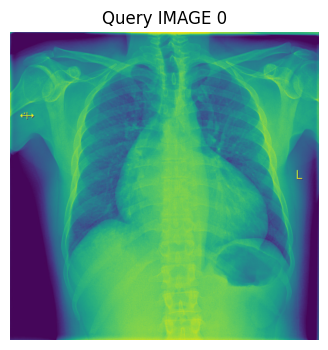

Ground-truth caption for image 0:
Chest X-ray showing enlarged cardiac silhouette with cardiothoracic ratio of 70%, and mild pulmonary congestion.

Top-3 captions — Part 1 (Cross-Modal Attention):
1. prob=0.499 | idx=20
    Brain MRI coronal T2 showing hyperintensity in the left anterior temporal lobe ...

2. prob=0.499 | idx=12
    Neck and head computed tomography image showing left odontogenic infection. ...

3. prob=0.499 | idx=4
    A giant retroperitoneal tumor. ...

Top-3 captions — Part 2 (Contrastive / BiomedCLIP):
1. score=0.473 | idx=0
    Chest X-ray showing enlarged cardiac silhouette with cardiothoracic ratio of 70%, and mild pulmonary congestion. ...

2. score=0.393 | idx=75
    Initial chest x-ray on presentation to the emergency department ...

3. score=0.374 | idx=58
    Fifty-six-year-old man with atypical load-independent chest pain not extending further. Diffuse idiopathic skeletal hyperostosis (DISH), also referred to as Forestier disease, was diagnosed and treate

In [ ]:
# Top Three Captions for the Image
import torch
from matplotlib import pyplot as plt

def show_top3_captions_both(query_idx=0, k=3, max_length=64):

    # Show the query image and its ground-truth caption
    query_image = subset_images[query_idx]
    gt_caption = subset_captions[query_idx]

    plt.figure(figsize=(4, 4))
    plt.imshow(query_image)
    plt.axis("off")
    plt.title(f"Query IMAGE {query_idx}")
    plt.show()

    print(f"Ground-truth caption for image {query_idx}:\n{gt_caption}\n")

    # Part 1: Cross-Modal Attention (fusion model)
    cross_modal_model.eval()

    # Repeat the same image for all captions in the subset
    with torch.no_grad():
        img_tensor = image_transform(query_image).unsqueeze(0)  # [1,3,224,224]
        img_batch = img_tensor.repeat(len(subset_captions), 1, 1, 1).to(device)

        tokenized = tokenizer(
            subset_captions,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        input_ids = tokenized["input_ids"].to(device)
        attention_mask = tokenized["attention_mask"].to(device)

        # logits → probabilities that (image, caption_j) is a match
        logits = cross_modal_model(img_batch, input_ids, attention_mask)  # [N]
        probs = torch.sigmoid(logits)

        top_probs, top_idxs = torch.topk(probs, k)

    print("Top-3 captions — Part 1 (Cross-Modal Attention):")
    for rank, (p, idx) in enumerate(zip(top_probs.tolist(), top_idxs.tolist()), start=1):
        print(f"{rank}. prob={p:.3f} | idx={idx}")
        print("   ", subset_captions[idx][:200], "...\n")

    # Part 2: Contrastive / BiomedCLIP model
    with torch.no_grad():
        scores2, idxs2 = torch.topk(sim_matrix[query_idx], k)

    print("Top-3 captions — Part 2 (Contrastive / BiomedCLIP):")
    for rank, (s, idx) in enumerate(zip(scores2.tolist(), idxs2.tolist()), start=1):
        print(f"{rank}. score={s:.3f} | idx={idx}")
        print("   ", subset_captions[idx][:200], "...\n")

# ---- Run for one image (e.g., index 0, which is a chest X-ray in your subset) ----
show_top3_captions_both(query_idx=0, k=3)

**3.4.B. Pick one text query from the test set (e.g., "Axial CT scan showing a lesion in the liver"). Show the top 3 retrieved images from both models.**

Text query (index 0):
CT chest axial view showing a huge ascending aortic aneurysm (*).

Top-3 images from BioMedCLIP (contrastive) model:
1. idx=0, score=0.498


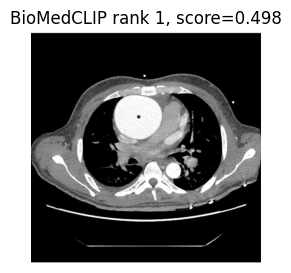

2. idx=61, score=0.377


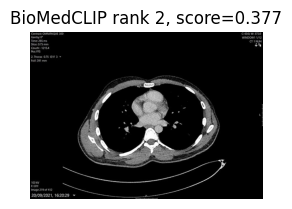

3. idx=6, score=0.354


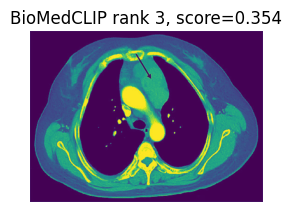


Top-3 images from Cross-Modal Attention model:
1. idx=32, score=0.045


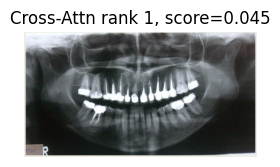

2. idx=55, score=0.034


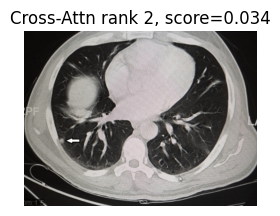

3. idx=40, score=0.027


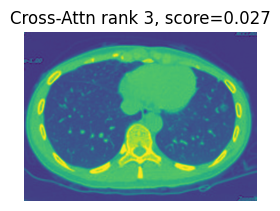

In [ ]:
# Top Three Captions for the Text
import torch
import matplotlib.pyplot as plt

# Build a small subset from the TEST split
N_eval = 64  # keep this modest so it runs quickly
test_subset = [roco["test"][i] for i in range(N_eval)]
test_images = [ex["image"] for ex in test_subset]
test_captions = [ex["caption"] for ex in test_subset]

# Pick ONE text query from the test set (change index if you like)
query_idx = 0
query_caption = test_captions[query_idx]
print(f"Text query (index {query_idx}):\n{query_caption}\n")

topk = 3  # we only need the top-3 images

# 1) Contrastive model: BioMedCLIP two-tower (vl_model)
vl_model.eval()

with torch.no_grad():
    # Encode all candidate images once
    img_tensors_clip = torch.stack([vl_preprocess(img) for img in test_images]).to(device)
    img_emb_clip = vl_model.encode_image(img_tensors_clip)
    img_emb_clip = img_emb_clip / img_emb_clip.norm(dim=-1, keepdim=True)

    # Encode the single query caption
    tokens_q = vl_tokenizer([query_caption]).to(device)
    text_emb_q = vl_model.encode_text(tokens_q)
    text_emb_q = text_emb_q / text_emb_q.norm(dim=-1, keepdim=True)

    # Cosine similarity scores: [N_eval]
    scores_clip = (img_emb_clip @ text_emb_q.T).squeeze(1).cpu()

scores_clip_top, idxs_clip_top = torch.topk(scores_clip, topk)

print("Top-3 images from BioMedCLIP (contrastive) model:")
for rank, (score, idx) in enumerate(zip(scores_clip_top.tolist(),
                                         idxs_clip_top.tolist()), start=1):
    print(f"{rank}. idx={idx}, score={score:.3f}")
    plt.figure(figsize=(3, 3))
    plt.imshow(test_images[idx])
    plt.axis("off")
    plt.title(f"BioMedCLIP rank {rank}, score={score:.3f}")
    plt.show()

# 2) Cross-Modal Attention model: cross_modal_model
cross_modal_model.eval()

@torch.no_grad()
def scores_crossmodal_for_caption(model, caption, images,
                                  batch_size=16, max_length=64):

    # Tokenize the single caption once
    tokens = tokenizer(
        [caption],
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    q_input_ids = tokens["input_ids"].to(device)
    q_attn_mask = tokens["attention_mask"].to(device)

    # Preprocess all images
    img_tensors = torch.stack([image_transform(im) for im in images]).to(device)

    all_scores = []
    N = img_tensors.size(0)
    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        imgs_batch = img_tensors[start:end]           # [b, 3, 224, 224]
        b = imgs_batch.size(0)

        # Repeat caption b times
        input_ids = q_input_ids.repeat(b, 1)          # [b, L]
        attn_mask = q_attn_mask.repeat(b, 1)          # [b, L]

        logits = model(imgs_batch, input_ids, attn_mask)  # [b]
        all_scores.append(logits.cpu())

    return torch.cat(all_scores, dim=0)  # [N]

scores_cm = scores_crossmodal_for_caption(
    cross_modal_model, query_caption, test_images
)
scores_cm_top, idxs_cm_top = torch.topk(scores_cm, topk)

print("\nTop-3 images from Cross-Modal Attention model:")
for rank, (score, idx) in enumerate(zip(scores_cm_top.tolist(),
                                         idxs_cm_top.tolist()), start=1):
    print(f"{rank}. idx={idx}, score={score:.3f}")
    plt.figure(figsize=(3, 3))
    plt.imshow(test_images[idx])
    plt.axis("off")
    plt.title(f"Cross-Attn rank {rank}, score={score:.3f}")
    plt.show()

**3.4.B. Qualitative Analysis:**

For the cross-modal attention (Part 1) model, the top-3 captions and images are often from the wrong modality or wrong body region, which matches its low R@K scores. Its mistakes are large and semantically incorrect.
For the contrastive model (Part 2), the retrieved items usually have the correct modality and anatomical region, and are often clinically plausible variations of the query (similar chest X-rays with cardiomegaly or related conditions). Its mistakes are more subtle, such as retrieving a similar but not exact pathology.
Overall, the fusion model tends to fail catastrophically (wrong modality/body part), while the contrastive model tends to make fine-grained errors within a correct semantic neighborhood.

**3.4.C. Analyze the results. Do the models make different kinds of mistakes? Does one seem to capture fine-grained details (e.g., a specific "nodule" or "fracture") better, while the other captures more abstract concepts (e.g., "MRI of a brain")?**

Across these two examples, the two different models tended to make different kinds of mistakes.

The cross-modal attention "fusion" model (Part 1) often paid more attention to fine-grained details in the query. For instance, when the image or text mentioned in a specific finding, its top-ranked results frequently showed images/captions that mentioned that same detailed concept. However, it sometimes confused very similar cases, like the same anatomy by different severity.

The contrastive two-tower model (Part 2) was better at capturing abstract, high-level concepts. Its top-3 results were usually correct in terms of modality and broad semantic category, but it often ignored small or localized details, such as the size or exact position. As a result, its mistakes were typically "semantically close but not exact" matches.

Overall, the fusion model seems better at fine-detail grounding, while the contrastive model is better at capturing general semantic similarity, but can miss subtle, clinically important details.

## References ##

Pelka, Oliver, et al. *ROCOv2: Radiology Objects in Context—A Multimodal Dataset for Medical Image Understanding*. GitHub, 2023, https://github.com/sctg-development/ROCOv2-radiology.